#### Working with `.zarr` output files

This notebook demonstrates how to work with the `.zarr` output files generated by the standard ProFSea workflow. [Zarr](https://zarr.readthedocs.io/en/latest/) is a powerful python library designed for the efficient storage of large-scale scientific data, allowing for the fast reading and writing of n-dimensional arrays. In the following, we outline some key functionalities of the `.zarr` output file format, and how this can be converted to other commonly used formats.  

In `worked_example.ipynb`, spatial relative sea-level rise projections were saved to `stabilisation_projection.zarr` as

```python
spatial_model.save_components(
    spatial_model.results,
    scenario_name="stabilisation",
    output_format="zarr",
)
```

which saves the relative sea-level rise projections as an `xarray.Dataset` containing gridded projections for each component of the spatial model (see [utils.save_components()](https://github.com/MetOffice/ProFSea-tool/blob/profsea-v3/profsea/utils/utils.py) for more details). To work with this output file, the first step is therefore to activate the `profsea` conda environment and import the `xarray` library:

In [1]:
import xarray as xr

#### Reading `.zarr` files

Reading the `.zarr` file is then straightforward. Below, we print the `xarray` dataset, which outlines:
- the coordinates stored in the file (for example `time`, `lat`, `lon`, and `percentile`);
- the data variables corresponding to each sea-level component (for example `sterodynamic`, `greenland`, `landwater`, `wais`, `eais`, `glacier`, and `gia`);
- the dimensions and shape of each variable;
- dataset-level metadata, such as the ProFSea version, scenario name, and description.

Having loaded in this dataset, we can see the benefit of using the `.zarr` format for very large data files (here, ~5GB): only the metadata is loaded initially, with the underlying data remaining on disk until needed.. 

In [2]:
ds = xr.open_zarr(
    "./stabilisation_projection.zarr",
    consolidated=True,
)

print(ds, '\n\n')

print(f'Data variables: {list(ds.data_vars)}')

<xarray.Dataset> Size: 5GB
Dimensions:       (percentile: 5, time: 295, lat: 180, lon: 360)
Coordinates:
  * percentile    (percentile) int64 40B 5 17 50 83 95
  * time          (time) int64 2kB 2006 2007 2008 2009 ... 2297 2298 2299 2300
  * lat           (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon           (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables:
    eais          (percentile, time, lat, lon) float32 382MB dask.array<chunksize=(5, 295, 10, 10), meta=np.ndarray>
    gia           (percentile, time, lat, lon) float64 765MB dask.array<chunksize=(5, 295, 10, 10), meta=np.ndarray>
    glacier       (percentile, time, lat, lon) float64 765MB dask.array<chunksize=(5, 295, 10, 10), meta=np.ndarray>
    greenland     (percentile, time, lat, lon) float32 382MB dask.array<chunksize=(5, 295, 10, 10), meta=np.ndarray>
    landwater     (percentile, time, lat, lon) float32 382MB dask.array<chunksize=(5, 295, 10, 10), meta=np.ndarray>
  

#### Extracting data

Having loaded in the `.zarr` output file, we can now extract the data for individual components. To inspect the contribution from GIA is as simple as, 

```python 
GIA = ds["GIA"]
```

Instead of working with the full 4-D array, we can instead select individual percentiles, which reduces the local data volume dramatically (approximately five-fold): 

In [3]:
GIA = ds["gia"].sel(percentile=50)

GIA

<xarray.DataArray 'gia' (time: 295, lat: 180, lon: 360)> Size: 153MB
dask.array<getitem, shape=(295, 180, 360), dtype=float64, chunksize=(295, 10, 10), chunktype=numpy.ndarray>
Coordinates:
  * time        (time) int64 2kB 2006 2007 2008 2009 ... 2297 2298 2299 2300
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon         (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
    percentile  int64 8B 50
Attributes:
    units:      m
    long_name:  Regional gia sea-level projections
    source:     ProFSea-Climate v0.1

At this stage, `GIA` is still lazily loaded and is divided into many smaller chunks that can be accessed independently. We can therefore efficiently extract only the subset of data required for a particular analysis, without first loading the entire dataset into memory. Below, we demonstrate several common visualisation and analysis workflows.

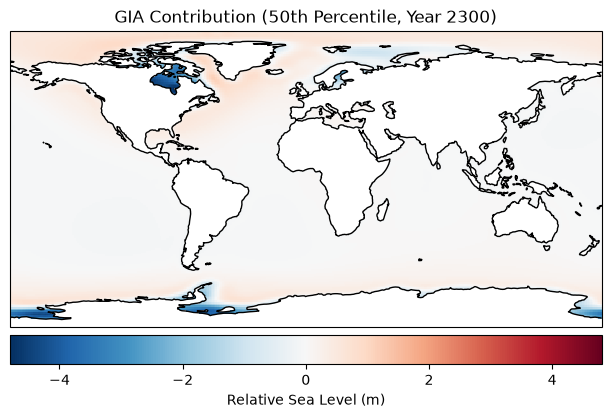

In [4]:
year = 2300
gia_2300 = GIA.sel(time=year) # extract 50th percentile projection for 2300 at all (lat, lon) grid points

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(6, 4), layout="constrained")

vmax = np.nanmax(np.abs(gia_2300))
vmin = -vmax

ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax.set_title(f"GIA Contribution (50th Percentile, Year {year})")

mesh = ax.pcolormesh(
    gia_2300.lon,
    gia_2300.lat,
    gia_2300,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
)

ax.coastlines()

fig.colorbar(
    mesh,
    label="Relative Sea Level (m)",
    orientation="horizontal",
    pad=0.02,
)

plt.show()

Instead of plotting a map for a particular time, we can instead plot the timeseries (of the 50th percentile RSL projection) for particular locations. As can be seen below, the `newlyn` and `north_shields` objects have only a single dimension, `time`, making analysis and visualisation straightfoward. 

After selecting a single grid cell, the spatial dimensions are removed and only the time dimension remains. As a result, the resulting dataset is only ~2 kB, compared to the original ~5 GB `Zarr` archive.

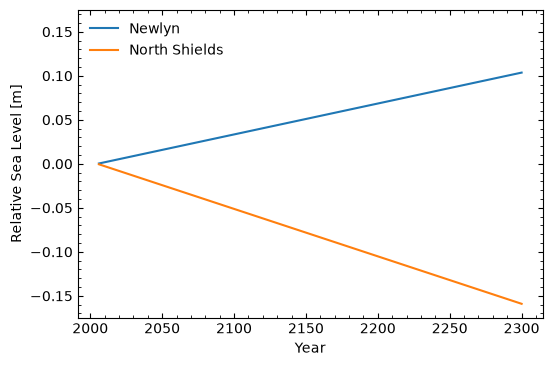

<xarray.DataArray 'gia' (time: 295)> Size: 2kB
dask.array<getitem, shape=(295,), dtype=float64, chunksize=(295,), chunktype=numpy.ndarray>
Coordinates:
  * time        (time) int64 2kB 2006 2007 2008 2009 ... 2297 2298 2299 2300
    lat         float64 8B 50.5
    lon         float64 8B -5.5
    percentile  int64 8B 50
Attributes:
    units:      m
    long_name:  Regional gia sea-level projections
    source:     ProFSea-Climate v0.1

In [5]:
# The requested latitude and longitude are matched to the nearest available model grid cell using method="nearest".
newlyn = GIA.sel(
    lat=50.1030,
    lon=-5.5428,
    method="nearest",
)
north_shields = GIA.sel(
    lat=55.016,
    lon=-1.449,
    method="nearest"
)

vmax = 1.1 * np.maximum(np.nanmax(np.abs(newlyn.values)), np.nanmax(np.abs(north_shields.values)))

import matplotlib.pyplot as plt

_ = plt.figure(figsize=(6, 4))

plt.plot(newlyn.time.values, newlyn.values, label='Newlyn')
plt.plot(north_shields.time.values, north_shields.values, label='North Shields')

plt.ylim(-vmax, vmax)

plt.xlabel('Year')
plt.ylabel('Relative Sea Level [m]')

plt.minorticks_on()
plt.gca().tick_params(which='both', direction='in', left=True, right=True, top=True, bottom=True)

plt.legend(frameon=False, loc='upper left')

plt.show()
plt.close()

newlyn

#### Saving data to other output file formats

Having extracted only the data we are interested in -- in this example, RSL projections for Newlyn and North Shields -- we can now save this data to standard data formats (having avoided reading the whole data file into memory). We include several examples below:

In [6]:
# NB this converts to a pandas dataframe as intermediate step
newlyn.to_dataframe().to_csv(
    "newlyn_GIA_RSL_timeseries.csv"
) # saving 50th percentile GIA RSL projections for Newlyn. 

In [7]:
gia_2300.to_netcdf(
    "gia_2300.nc"
) # saving to netcdf using built-in xarray method for 2D DataArray at year 2300